# Key findings

1. Dataset Overview: 

    - 21 features covering demographics, services subscribed, contract details, and billing. 
    - Data is clean, no missing values or duplicates.
    - Target variable is 'Churn' (Yes/No).


2. Class Imbalance:

    - The dataset is imbalanced with 73.5 customers has not churned and 26.5% of the customers have churned. 
    - Evaluate model performance with ROC-AUC, F1 score
    - Might need SMOTE or class-weight adjustments during modeling.

3. key Features Correlated with Churn:


     a. Contract Type: Month-to-month contracts have higher churn rates.
     -  Buisness recommendation: Create targeted incentives - such as discounts, promotional pricing, or added benefits to encourage monthly customers to switch to annual contracts

     b. Tenure: Customer with shorter tenure are more likely to churn.
     - Business rececommendation: Offer some retention efforts for the new customers (< 1 year)

    c. Monthly charges : Higher monthly paying customers are more likely to churn could be due to not feeling for value for money.
    - Business recommendation: Consider offering flexible pricing plans or discounts for high-paying customers, proactive negagement and value-added srvices/offers.

    d. Key services: Customers without key services especially tech support and online security are more likely to churn. 
                Fibre optics customers have higher churn rates due to higher monthly charges.
    - Business recommendation: Offer services, discounted packages and promotions to customers


    e. Senior citizens: Senior citizens represent a relatively small share of the customer base, but their churn rate is disproportionately higher than that of younger customer segments. This could be due to difficulty navigating the service, usability barriers, or greater price sensitivity.
    - Business recommendation: Consider offering senior-friendly services, onboarding, dedicated support lines, or tailored pricing cater to this demographic.



4. Correlation Analysis:
    - Tenure is negatively correlated with Churn, indicating that customers with longer tenure are less likely to churn.
    - Tenure and total charges are highly positvely correlated. This could cause multicollinearity issues in the model. Consider dropping one of these features or using regularization techniques to mitigate this issue.



# Import , Load and Inspect


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('kaggle_raw_data.csv')
print(df.shape)         
df.head()
df.info()
df.describe()
df.isnull().sum()





(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

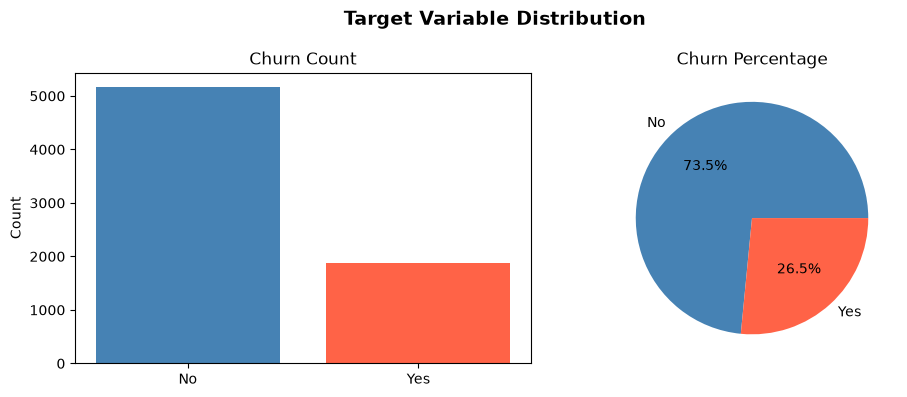

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
#Target value distribution

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Count')

axes[1].pie(churn_pct.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Churn Percentage')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

print(churn_pct)

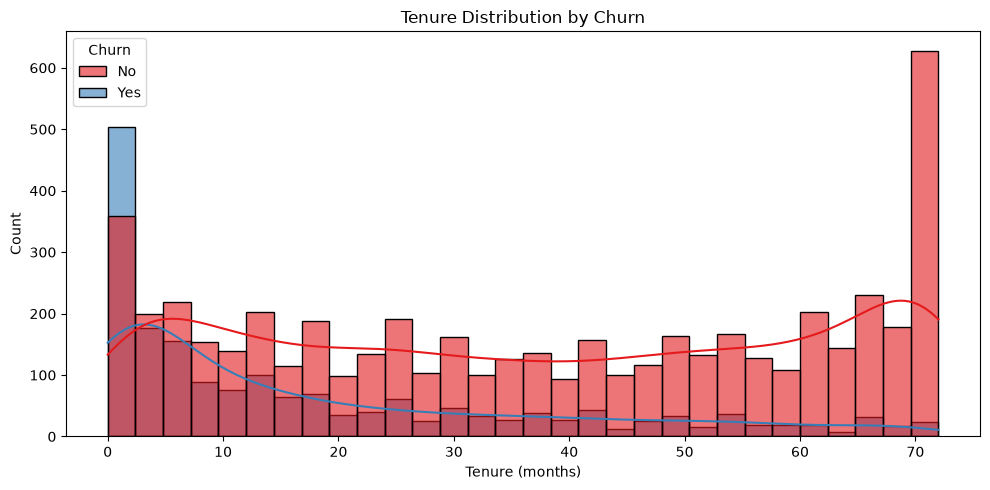

In [ ]:
# Churn distribution by Tenure
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             kde=True, palette='Set1', alpha=0.6)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150)
plt.show()

/var/folders/rh/x8rtcsmd4hd9n6yft69qcc680000gn/T/ipykernel_17102/4217239470.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


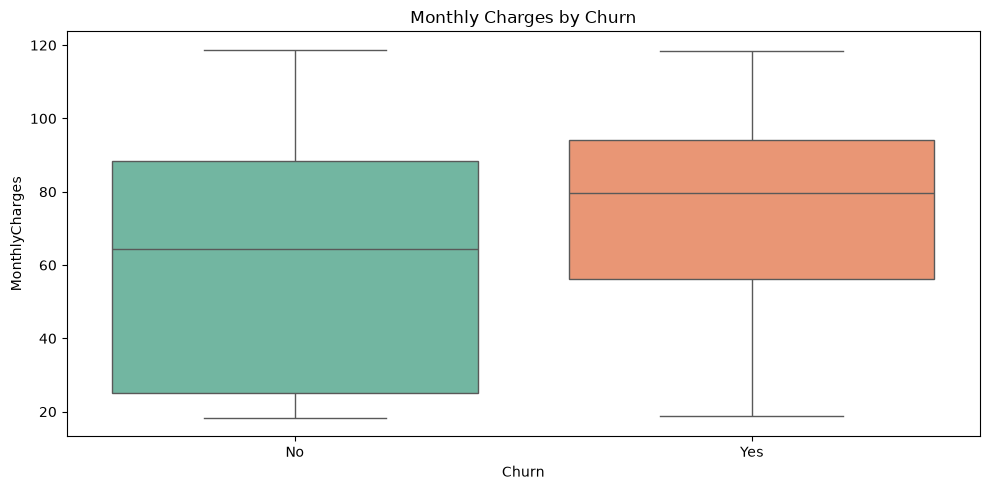

In [ ]:
# Monthy charges distribution by Churn
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges by Churn')
plt.tight_layout()
plt.savefig('monthly_charges_churn.png', dpi=150)
plt.show()

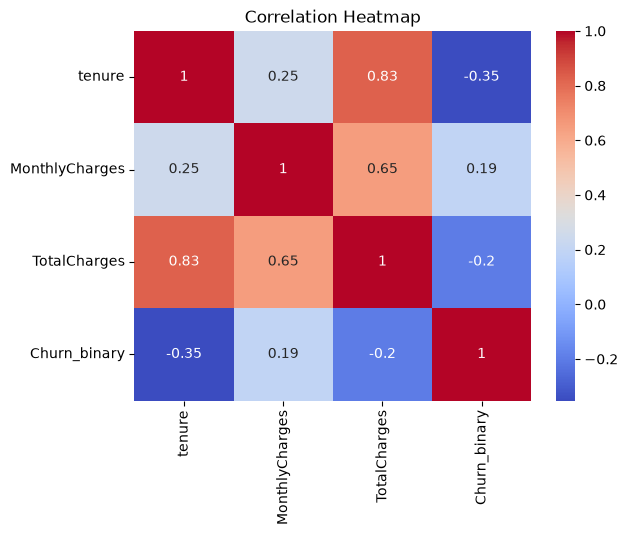

In [ ]:
#Correlation heatmap
# converting total charges to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

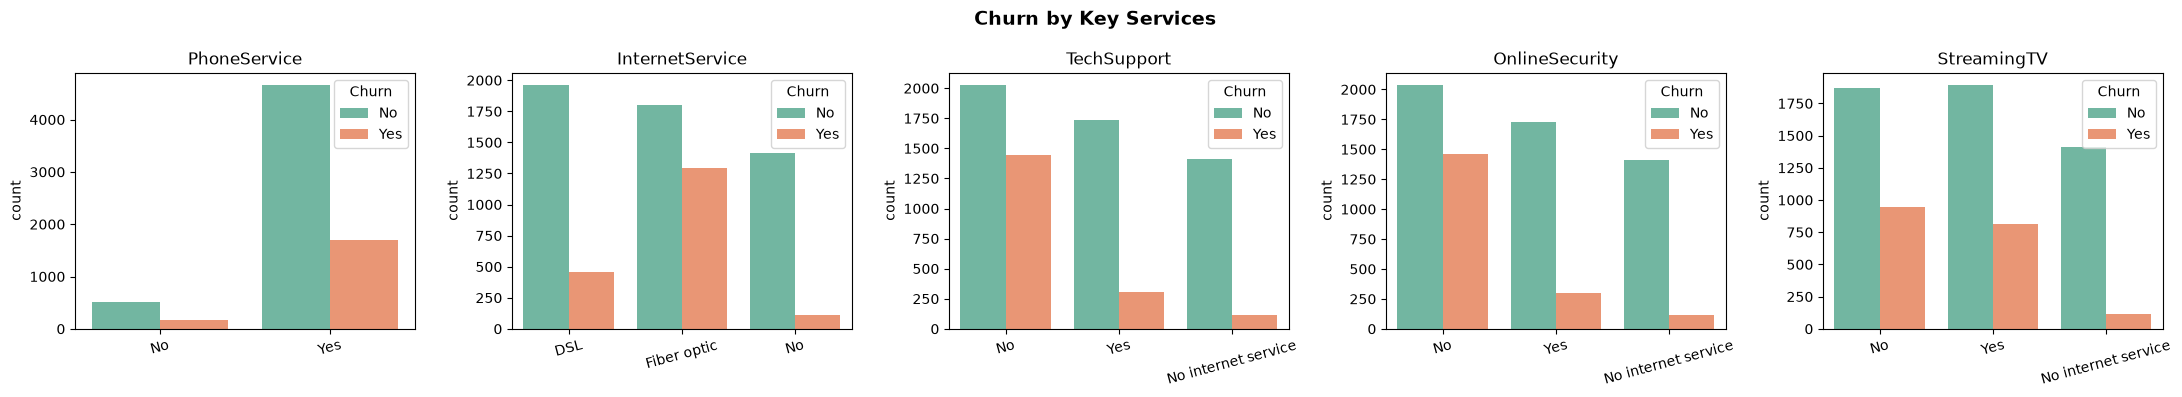

In [ ]:
# churn distribution by key services
services = ['PhoneService', 'InternetService', 'TechSupport',
            'OnlineSecurity', 'StreamingTV']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, col in enumerate(services):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Churn by Key Services', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_services.png', dpi=150)
plt.show()


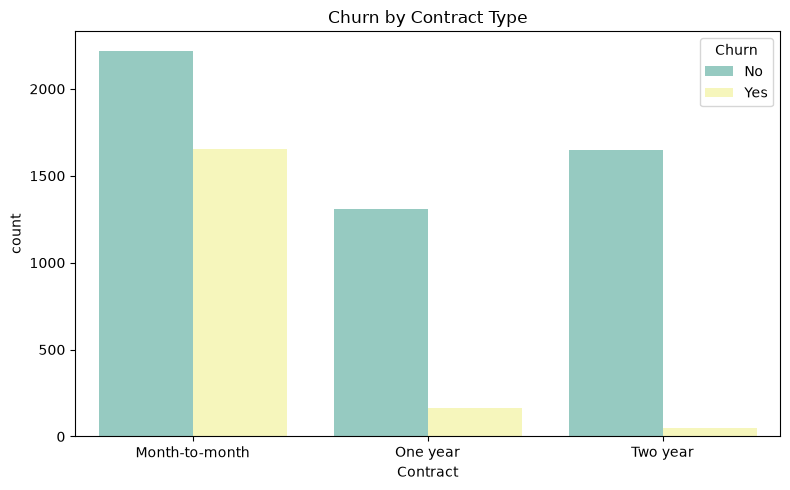

In [ ]:
#Churn distirbution by Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set3')
plt.title('Churn by Contract Type')
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)   

/var/folders/rh/x8rtcsmd4hd9n6yft69qcc680000gn/T/ipykernel_17102/2402116239.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Not Senior', 'Senior'])


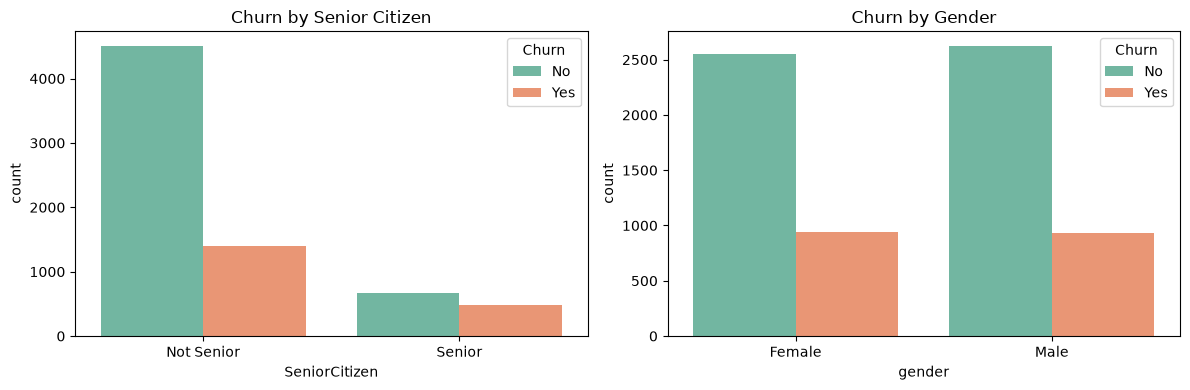

In [ ]:
#Churn distribution by senior citizen status and gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Senior Citizen')
axes[0].set_xticklabels(['Not Senior', 'Senior'])

sns.countplot(data=df, x='gender', hue='Churn', ax=axes[1], palette='Set2')
axes[1].set_title('Churn by Gender')

plt.tight_layout()
plt.savefig('churn_by_demographics.png', dpi=150)
plt.show()       